# 載入套件

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import datetime
from matplotlib.pyplot import MultipleLocator
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 載入清洗後資料

In [ ]:
data=pd.read_excel('/content/drive/MyDrive/Colab Notebooks/LTVfactors/新莊.xlsx') #在此修改讀取的檔案以載入三館資料
data

,FD,LD,Unnamed: 1,Unnamed: 2,No,單品名稱,Unnamed: 6,數量,會員等級備註\n@顯示折扣10%時－代表APP紅卡，一般紅卡\n@顯示折扣20%時－代表金卡，白金卡，鑽石卡,Unnamed: 11,收項時間,Unnamed: 13,類別名稱
0,2015-01-02,2015-03-07,30000,1,301283,暢飲加40元,10.0,1,0,0,2015-03-07 11:53:00,309.0,活動促銷
1,2015-01-02,2015-03-07,30000,1,301283,早上5小時入場票-假,287.0,1,10,10,2015-03-07 11:53:00,321.0,假日票券
2,2015-01-02,2015-03-07,30000,1,301283,暢飲加40元,10.0,1,0,0,2015-01-31 10:41:00,309.0,活動促銷
3,2015-01-02,2015-03-07,30000,1,301283,早上5小時入場票-假,287.0,1,10,10,2015-01-31 10:41:00,321.0,假日票券
4,2015-01-02,2015-03-07,30000,1,301283,暢飲加40元,10.0,1,0,0,2015-01-12 16:25:00,309.0,活動促銷
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22350,2021-04-21,2021-04-21,30000,1,304198,午晚90分鐘入場票-平,188.0,1,10,10,2021-04-21 16:18:00,320.0,平日票券
22351,2021-04-21,2021-04-21,30000,1,304198,辦卡禮-雙月體驗券,0.0,1,0,0,2021-04-21 15:52:00,323.0,會員卡
22352,2021-04-22,2021-04-22,30000,1,304199,午晚90分鐘入場票-平,188.0,2,10,10,2021-04-22 20:52:00,320.0,平日票券
22353,2021-04-28,2021-04-28,30000,1,70020342,午晚3小時入場票-平,218.0,7,10,10,2021-04-28 19:52:00,320.0,平日票券


# 假說驗證：來館6次後趨於穩定





> 計算來客天數



In [ ]:
#轉換為只有年月日
data['收項時間']=data['收項時間'].dt.date

In [ ]:
#同日只留一筆，以計算來客天數
day=data.drop_duplicates(subset=['No','收項時間'])
#每個id的統整資料放這個表
id=data.drop_duplicates(subset=['No'])
#來客天數建表
Day=day.groupby('No')
value=Day.size()
value1=pd.Series(value)
come = pd.DataFrame({'No':value1.index, '來客天數':value1.values})
#合併 #outer表示以聯集合併
data["No"] = data["No"].astype(str)
come["No"] = come["No"].astype(str)
id["No"] = id["No"].astype(str)
add_come = id[["No","FD",'LD','數量','收項時間','類別名稱','單品名稱']].merge(come[["No","來客天數"]],on ="No",how = 'outer')
add_come

<ipython-input-38-ba296090e964>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id["No"] = id["No"].astype(str)


,No,FD,LD,數量,收項時間,類別名稱,單品名稱,來客天數
0,301283,2015-01-02,2015-03-07,1,2015-03-07,活動促銷,暢飲加40元,6
1,301282,2015-01-02,2018-12-28,4,2018-12-28,活動促銷,暢飲加40元,2
2,301284,2015-01-03,2015-04-05,5,2015-01-03,假日票券,午晚3小時入場票-假,2
3,301285,2015-01-04,2018-04-06,1,2015-01-04,活動促銷,七獎-20點,3
4,301287,2015-01-04,2021-02-05,2,2021-02-05,平日票券,午晚3小時入場票-平,4
...,...,...,...,...,...,...,...,...
2676,304195,2021-04-17,2021-04-17,1,2021-04-17,會員卡,辦卡禮-雙月體驗券,1
2677,304198,2021-04-21,2021-04-21,1,2021-04-21,其他票券,午晚5小時體驗券-平,1
2678,304199,2021-04-22,2021-04-22,2,2021-04-22,平日票券,午晚90分鐘入場票-平,1
2679,70020342,2021-04-28,2021-04-28,7,2021-04-28,平日票券,午晚3小時入場票-平,1




> 計算消費間隔、標準差


In [ ]:
#消費間隔
day['上次消費日期']=day['收項時間'].shift(1)
day['消費間隔']=day['收項時間']-day['上次消費日期']
day['消費間隔']=day['消費間隔'].map(lambda x: x/np.timedelta64(1,'D'))
day_clean=day[(day['FD']!=day['收項時間'])] #把首次消費去除
day_clean=day[(day['上次消費日期']<day['收項時間'])]
day_clean

<ipython-input-39-07842e7202c8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day['上次消費日期']=day['收項時間'].shift(1)
<ipython-input-39-07842e7202c8>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day['消費間隔']=day['收項時間']-day['上次消費日期']
<ipython-input-39-07842e7202c8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

,FD,LD,Unnamed: 1,Unnamed: 2,No,單品名稱,Unnamed: 6,數量,會員等級備註\n@顯示折扣10%時－代表APP紅卡，一般紅卡\n@顯示折扣20%時－代表金卡，白金卡，鑽石卡,Unnamed: 11,收項時間,Unnamed: 13,類別名稱,上次消費日期,消費間隔
7,2015-01-02,2015-03-07,30000,1,301283,午晚3小時入場票-平,218.0,1,10,10,2015-01-09,320.0,平日票券,2015-01-02,7.0
9,2015-01-02,2018-12-28,30000,1,301282,暢飲加40元,15.0,4,0,0,2018-12-28,309.0,活動促銷,2015-01-09,1449.0
17,2015-01-03,2015-04-05,30000,1,301284,暢飲加40元,10.0,6,0,0,2015-04-05,309.0,活動促銷,2015-01-03,92.0
21,2015-01-04,2021-02-05,30000,1,301287,午晚3小時入場票-平,218.0,2,10,10,2021-02-05,320.0,平日票券,2015-01-04,2224.0
30,2015-01-04,2017-06-12,30000,1,301286,暢飲加40元,15.0,1,0,0,2017-06-12,309.0,活動促銷,2015-01-04,890.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22333,2021-04-14,2021-05-10,30000,1,70019560,午晚3小時入場票-平,218.0,1,10,10,2021-05-10,320.0,平日票券,2021-05-04,6.0
22346,2021-04-21,2021-04-21,30000,1,304198,午晚5小時體驗券-平,100.0,1,0,0,2021-04-21,322.0,其他票券,2021-04-17,4.0
22352,2021-04-22,2021-04-22,30000,1,304199,午晚90分鐘入場票-平,188.0,2,10,10,2021-04-22,320.0,平日票券,2021-04-21,1.0
22353,2021-04-28,2021-04-28,30000,1,70020342,午晚3小時入場票-平,218.0,7,10,10,2021-04-28,320.0,平日票券,2021-04-22,6.0


In [ ]:
#標準差（同天數一起）#改用頻率
std=day_clean.groupby(by=['No']).agg({'消費間隔':np.std})
std=std['消費間隔']
std1=pd.Series(std)
std2 = pd.DataFrame({'No':std1.index, '消費間隔標準差':std1.values})
std2=std2[(std2['消費間隔標準差']>0)]
std2["No"] = std2["No"].astype(str)
freq = add_come[["No","FD",'LD','數量','收項時間','類別名稱','來客天數']].merge(std2[["No","消費間隔標準差"]],on ="No",how = 'outer')
freq=freq[(freq['來客天數']>1)]#來不只一次
freq=freq.dropna(subset=['消費間隔標準差'])
freq

,No,FD,LD,數量,收項時間,類別名稱,來客天數,消費間隔標準差
3,301285,2015-01-04,2018-04-06,1,2015-01-04,活動促銷,3,574.170706
6,301288,2015-01-09,2019-04-17,2,2015-12-31,其他票券,10,597.503905
9,301295,2015-01-15,2021-02-10,22,2016-02-21,假日票券,4,1154.684950
11,301294,2015-01-16,2018-11-30,1,2018-04-29,會員卡,9,544.460895
13,301296,2015-01-18,2018-03-28,1,2015-01-18,活動促銷,5,347.069446
...,...,...,...,...,...,...,...,...
2632,70014632,2021-01-23,2021-04-30,1,2021-02-02,其他票券,2,55.154329
2643,70016248,2021-02-17,2021-04-17,1,2021-02-17,其他票券,3,2.121320
2649,70016833,2021-02-26,2021-03-16,2,2021-03-05,平日票券,2,3.535534
2660,70017982,2021-03-18,2021-05-08,1,2021-04-19,平日票券,10,13.524669




> 圖表呈現



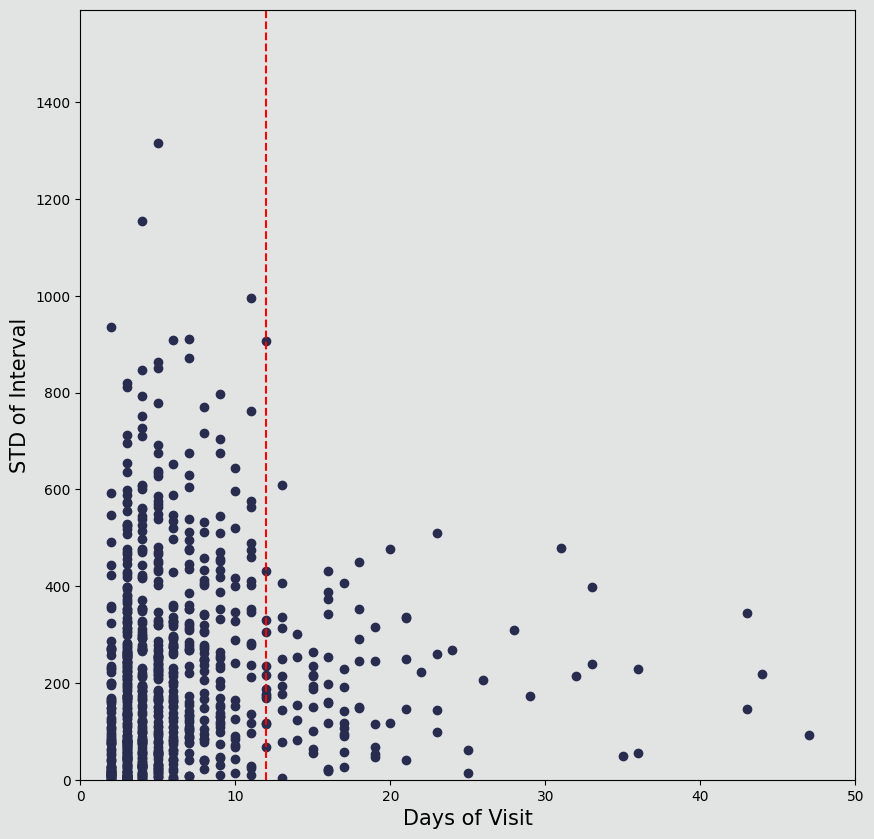

<Figure size 320000x240000 with 0 Axes>

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(10,10)

# 畫出散點圖
plt.scatter(x = "來客天數",y = '消費間隔標準差', data = freq,c='#282D4F')

#plt.title('Scatter plot of {} vs. {}'.format('Consumption Times','Average Order Value'))
plt.xlabel('Days of Visit',fontsize=15)
plt.ylabel('STD of Interval',fontsize=15)

plt.axvline(x=12,color ="red",linestyle = "--")

ax.set_facecolor('#E2E4E4')
fig.set_facecolor('#E2E4E4')


plt.xlim(0,50)
plt.ylim(0,1591)

#plt.figure(figsize=(20, 8))
plt.figure(dpi=50000)
plt.show()

# 假說驗證：最適來客人數為8人以下



> 計算每次消費同行人數（回訪）



In [ ]:
#留下類別名稱為平日票券、假日票券、其他票券的資料
people=data[((data['類別名稱']=='假日票券')|(data['類別名稱']=='平日票券')|(data['類別名稱']=='其它票券')|(data['單品名稱']=='贈紅卡'))]
people['下次消費日期']=people['收項時間'].shift(-1)
people_clean=people[(people['LD']!=people['收項時間'])]
people_clean=people[(people['下次消費日期']>people['收項時間'])]
people_clean1=people_clean[(people_clean['數量']>0)]
people_clean1
people_clean1=people_clean1.groupby(['No','收項時間'])['數量'].sum()
people_clean2=pd.Series(people_clean1)
people_clean3 = pd.DataFrame({'同行人數':people_clean2.values})
people_clean3

<ipython-input-29-e1b515bfe19a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  people['下次消費日期']=people['收項時間'].shift(-1)


,同行人數
0,1
1,4
2,1
3,8
4,8
...,...
82271,1
82272,2
82273,2
82274,7


> 計算每次消費同行人數（不再回訪）



In [ ]:
people_nback=people[(people['LD']==people['收項時間'])|(people['下次消費日期']<people['收項時間'])]
people_nback1=people_nback[(people['數量']>0)]
people_nback1=people_nback1.groupby(['No','收項時間'])['數量'].sum()
people_nback2=pd.Series(people_nback1)
people_nback3 = pd.DataFrame({'同行人數':people_nback2.values})
people_nback3

<ipython-input-30-25594e57931a>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  people_nback1=people_nback[(people['數量']>0)]


,同行人數
0,2
1,2
2,4
3,4
4,3
...,...
13959,5
13960,1
13961,7
13962,2




> 相同人數為一類判斷是否有再次消費



In [ ]:
Num=people_clean3.groupby('同行人數')
Num1=Num.size()
Num2 = pd.DataFrame({'同行人數':Num1.index, '有回訪次數':Num1.values})

In [ ]:
nNum=people_nback3.groupby('同行人數')
nNum1=nNum.size()
nNum2 = pd.DataFrame({'同行人數':nNum1.index, '無回訪次數':nNum1.values})



> 算出回訪比率



In [ ]:
back_percent=Num2[["同行人數","有回訪次數"]].merge(nNum2[["同行人數","無回訪次數"]],on ="同行人數",how = 'outer')
back_percent=back_percent.fillna(value=0)
back_percent['回訪比率']=back_percent['有回訪次數']/(back_percent['有回訪次數']+back_percent['無回訪次數'])
back_percent=back_percent[back_percent['有回訪次數']>5]
back_percent

,同行人數,有回訪次數,無回訪次數,回訪比率
0,1,42151.0,2187.0,0.950674
1,2,21915.0,3120.0,0.875374
2,3,7761.0,2088.0,0.787999
3,4,4982.0,2221.0,0.691656
4,5,2258.0,1197.0,0.653546
5,6,1198.0,937.0,0.561124
6,7,623.0,500.0,0.554764
7,8,382.0,421.0,0.475716
8,9,224.0,257.0,0.465696
9,10,154.0,188.0,0.450292




> 圖表呈現



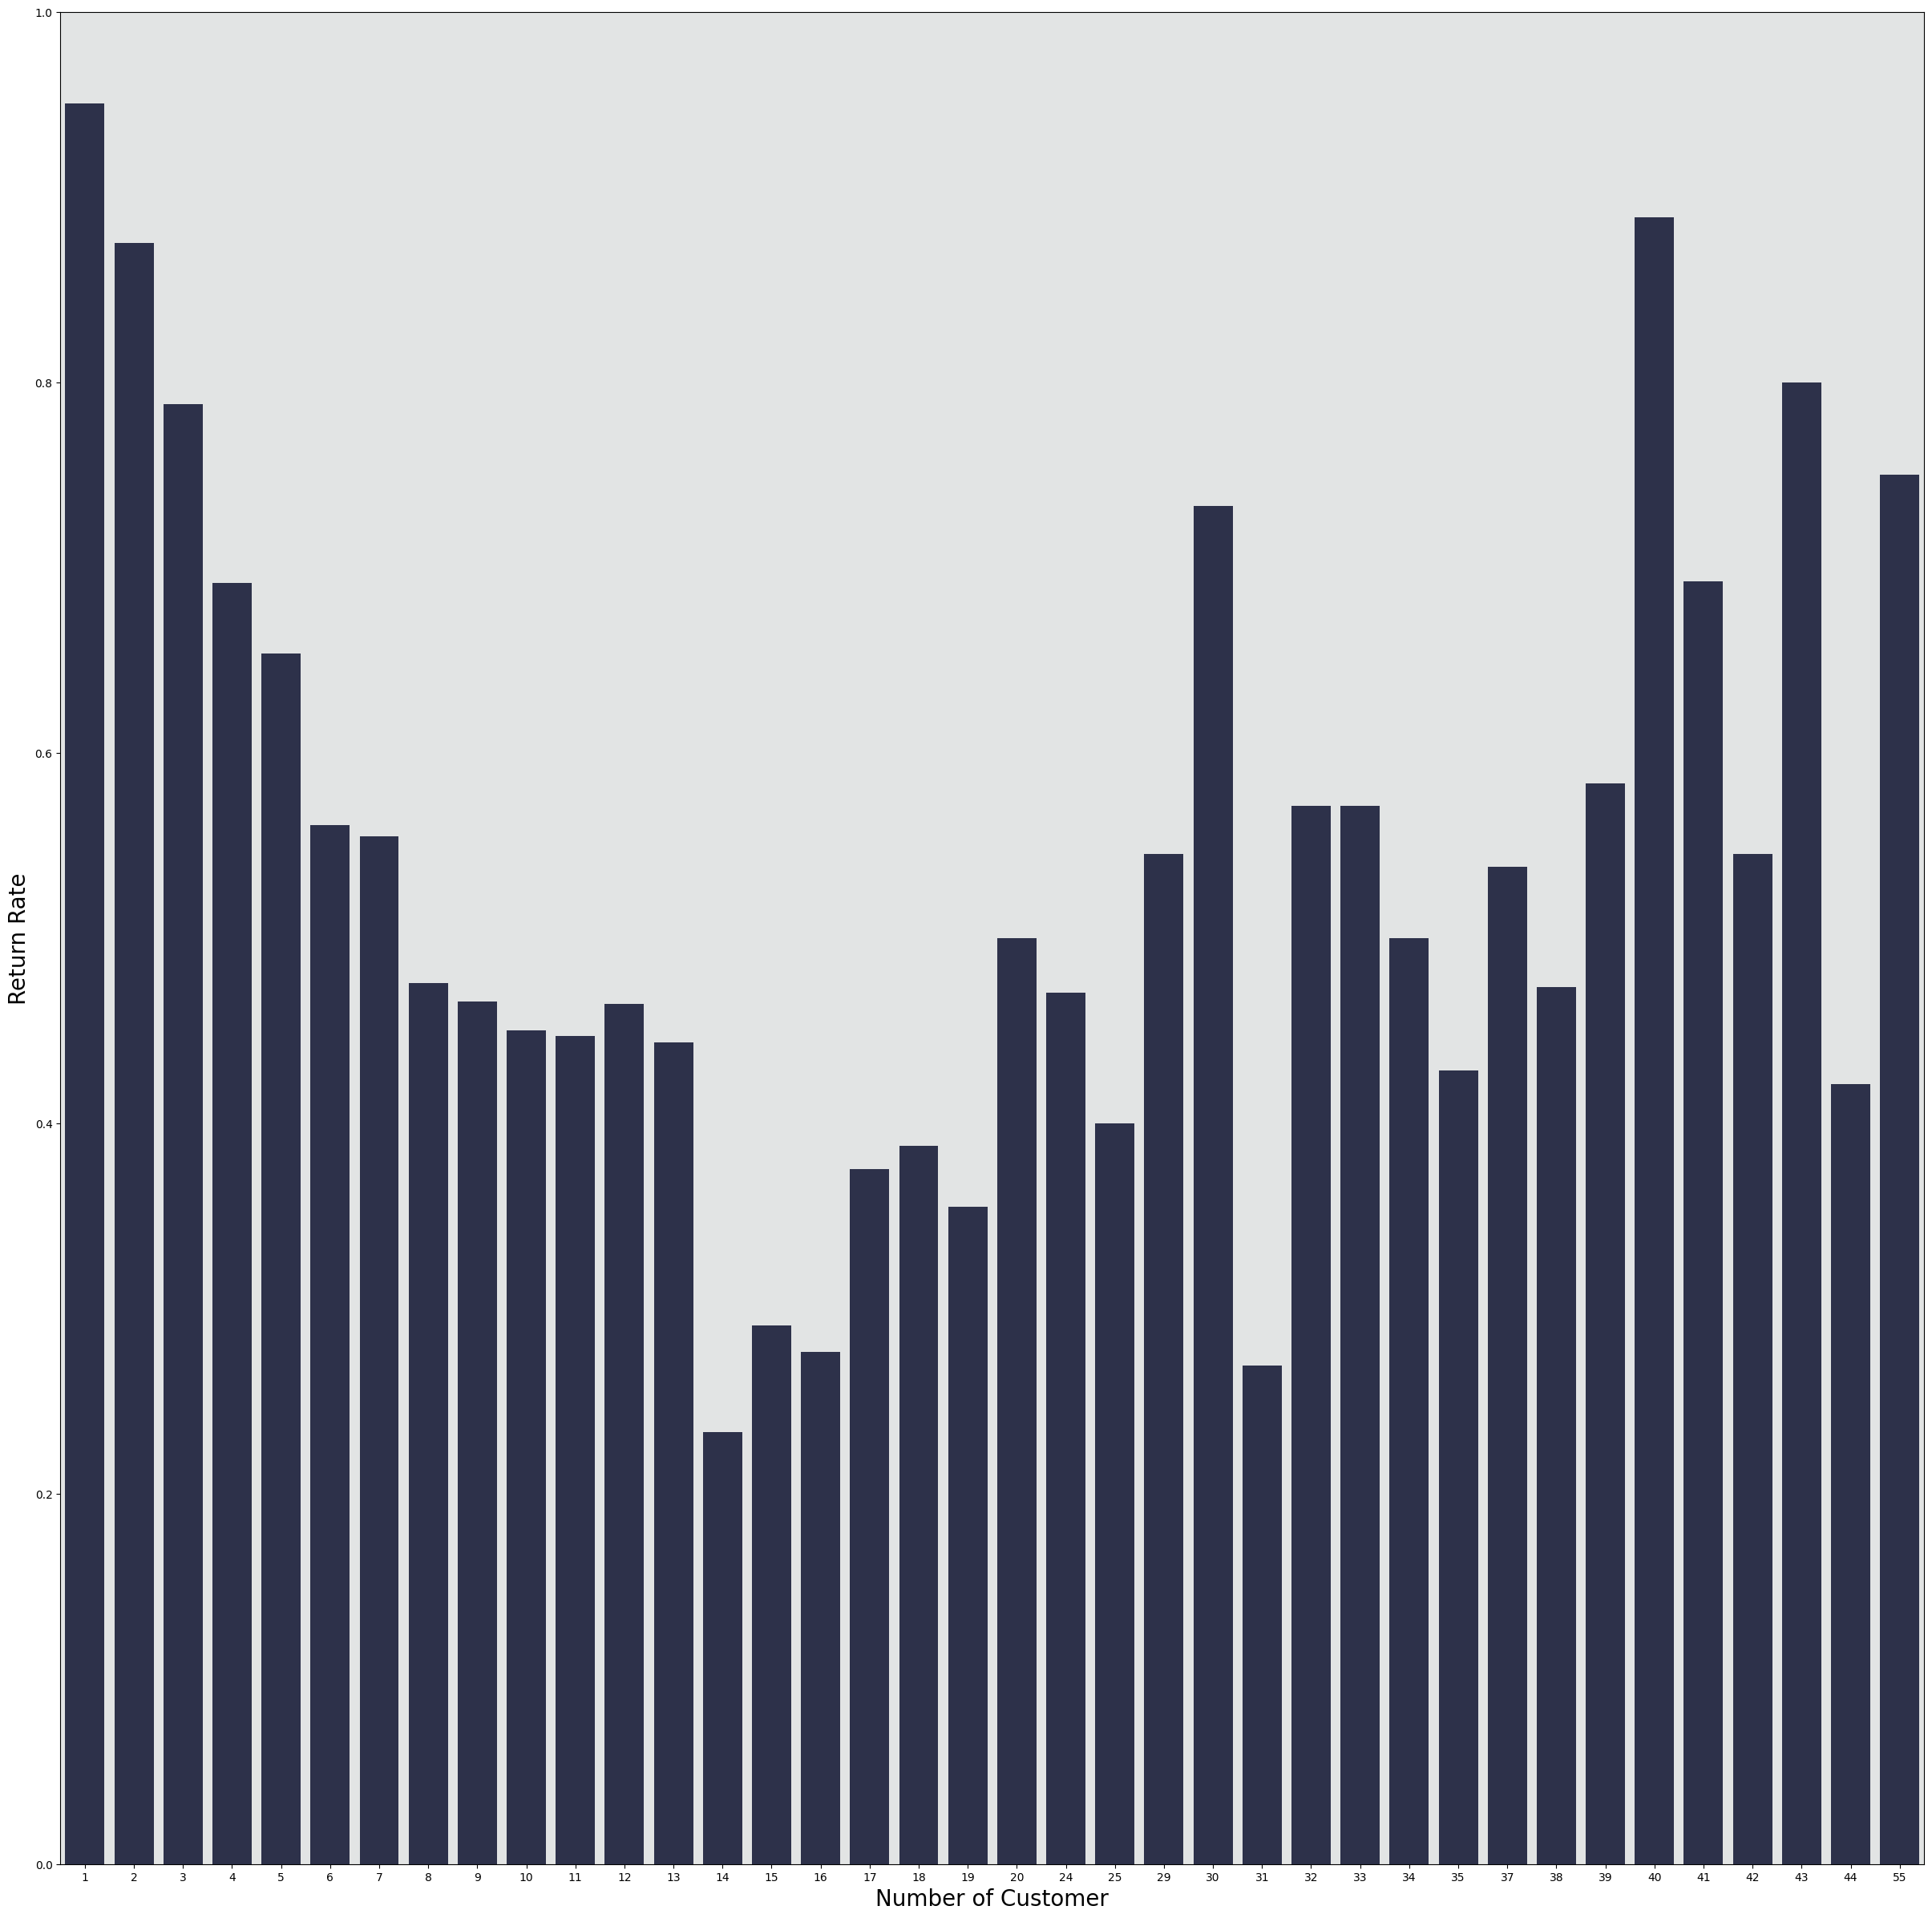

<Figure size 320000x240000 with 0 Axes>

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(30,30)

sns.barplot(x = "同行人數",y = '回訪比率', data = back_percent,color='#282D4F')

#plt.title('Scatter plot of {} vs. {}'.format('Consumption Times','Average Order Value'))
plt.xlabel('Number of Customer',fontsize=20)
plt.ylabel('Return Rate',fontsize=20)

ax.set_facecolor('#E2E4E4')
plt.ylim(0,1)
#plt.figure(figsize=(20, 8))
plt.figure(dpi=50000)
plt.show()

(0.0, 1.0)

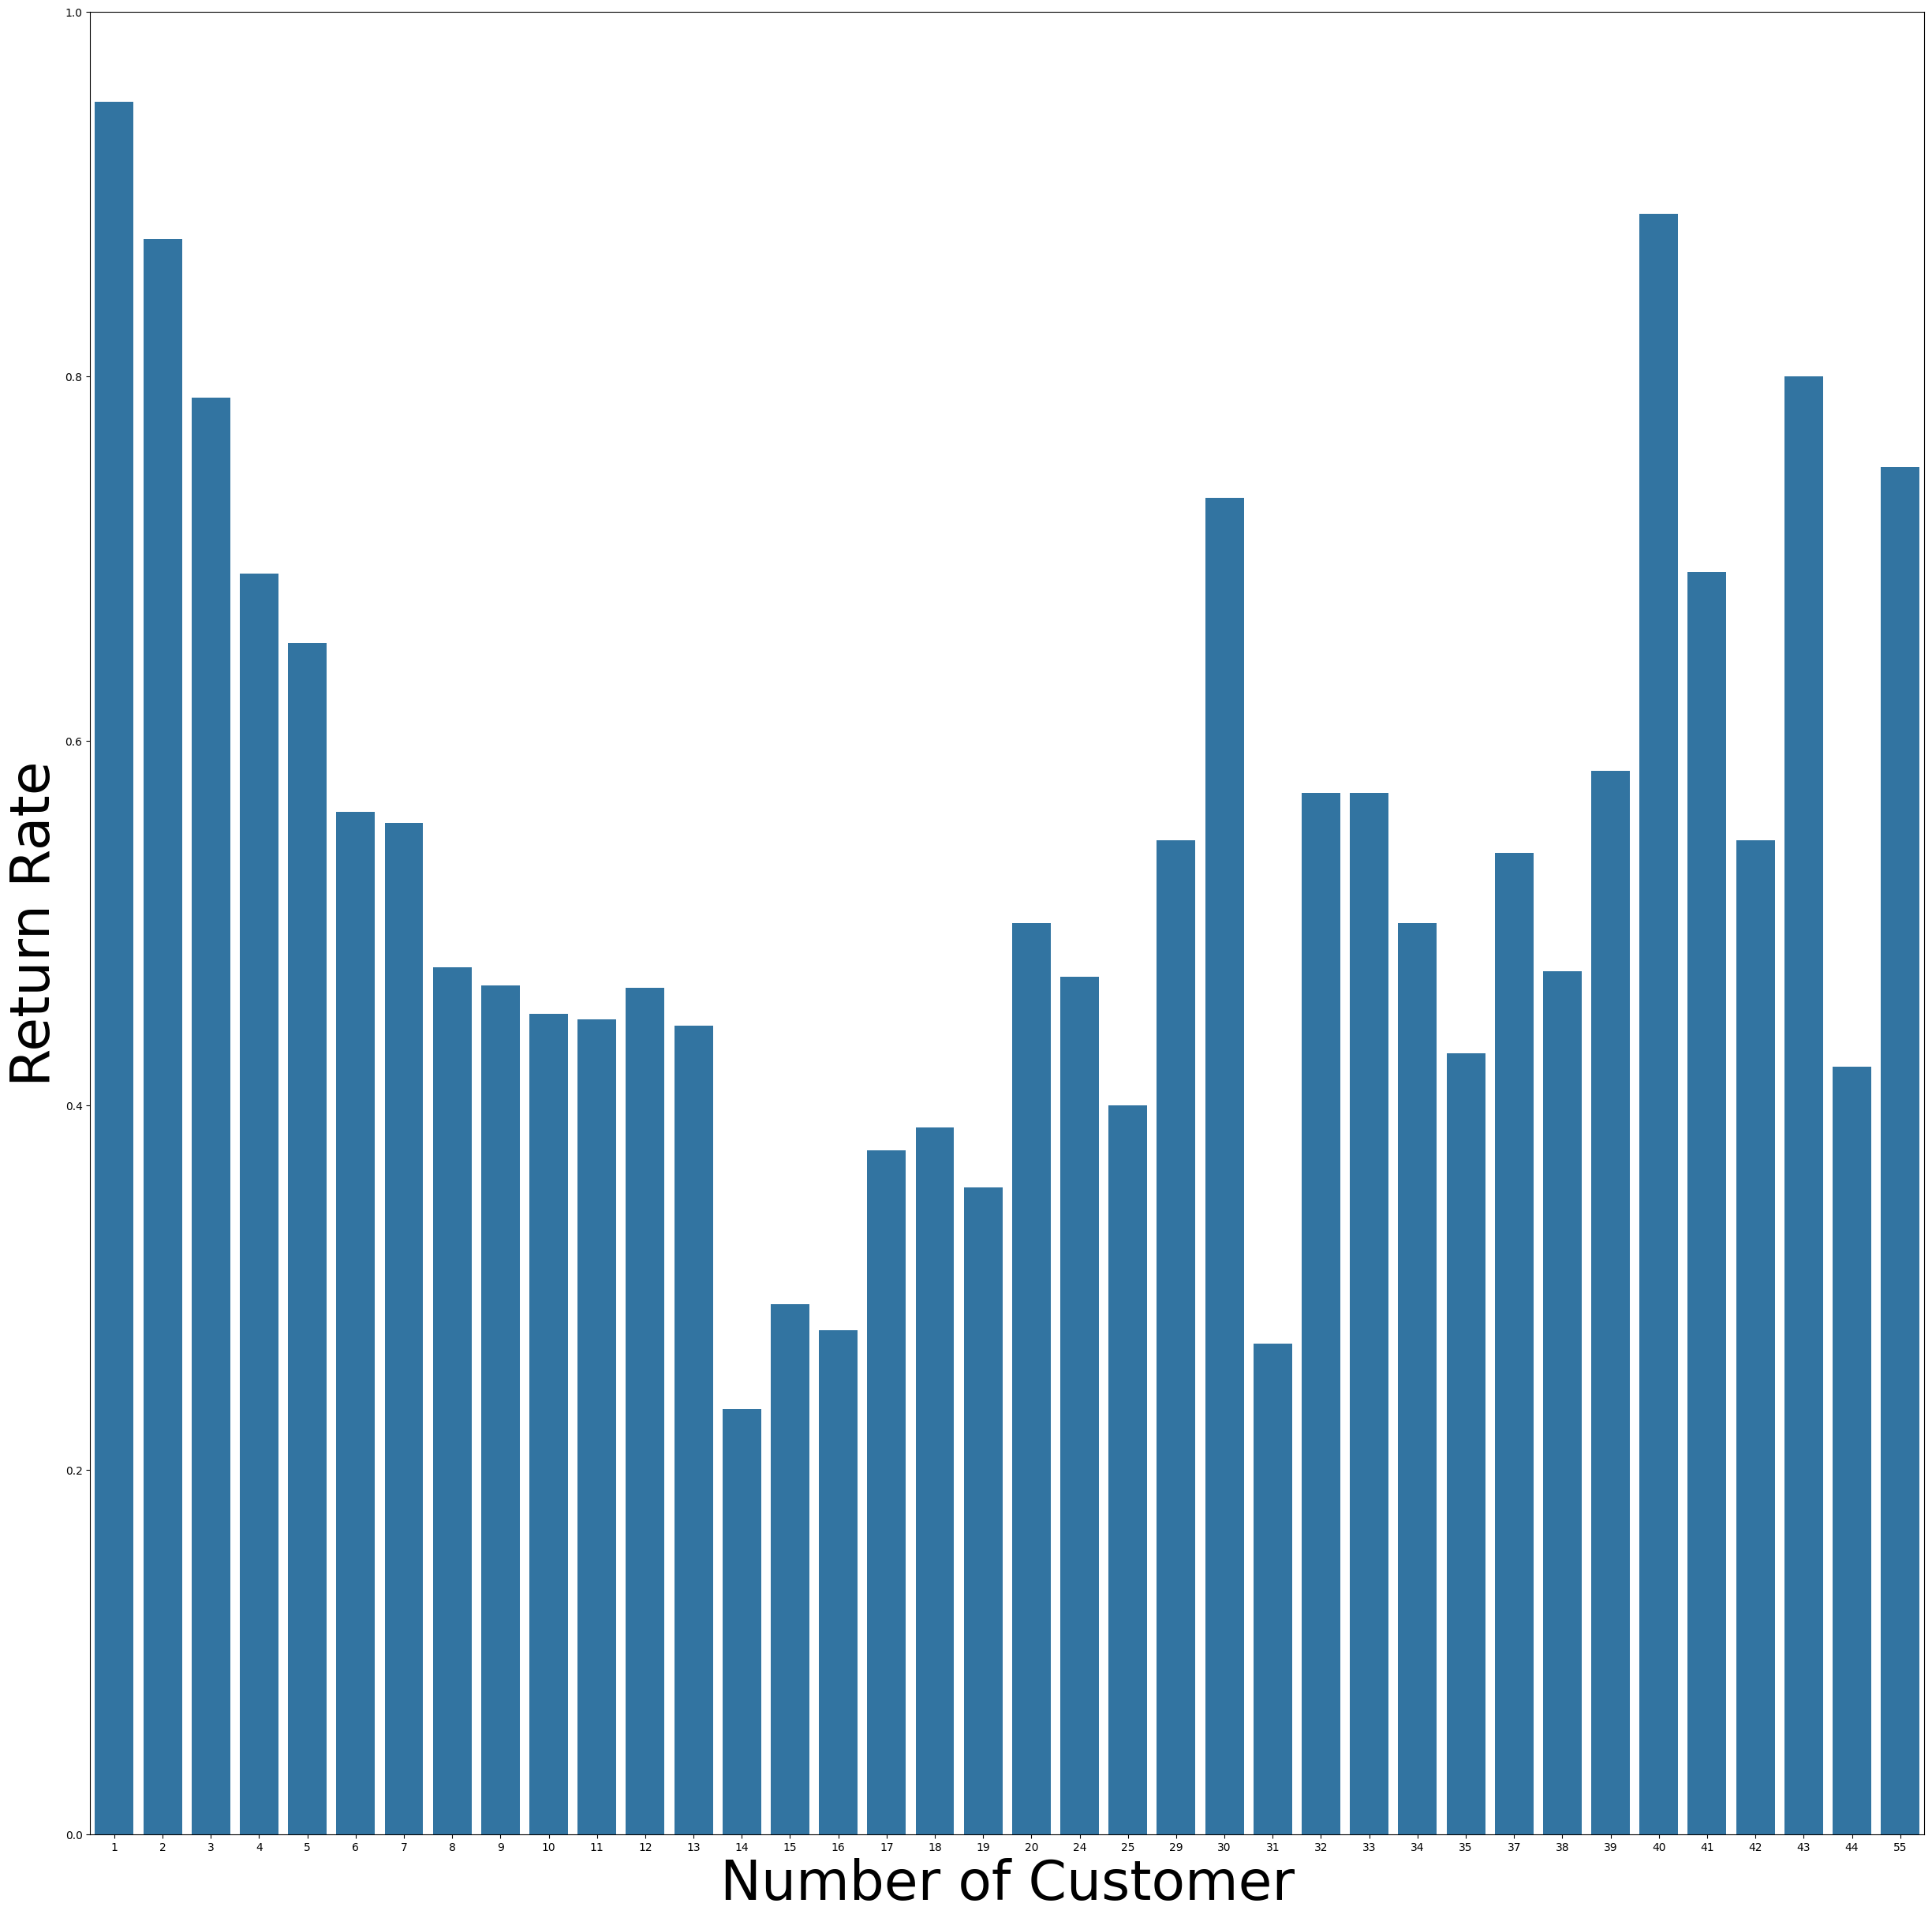

In [ ]:
#縱軸為消費同行人數，橫軸為回訪比率
plt.figure(figsize =(30,30))
sns.barplot(x = "同行人數",y = '回訪比率', data = back_percent,color='tab:blue')
plt.xlabel('Number of Customer',fontsize=50)
plt.ylabel('Return Rate',fontsize=50)
plt.ylim(0,1)